In [3]:
import numpy as np

data = np.load("sem_supervised_dataset.npz")
print(data.files)

['supervised_features', 'supervised_targets', 'supervised_targets_normalized', 'supervised_target_mean', 'supervised_target_std', 'training_hours', 'training_time_normalized', 'lat_downsampled', 'lon_downsampled', 'psi_qcl_training', 'psi_sem', 'zeta_sem', 'time_sem_hours', 'zeta_0']


In [10]:
import numpy as np

data = np.load("sem_supervised_dataset.npz")

print(data.files)

supervised_features = data["supervised_features"]
supervised_targets = data["supervised_targets"]
supervised_targets_normalized = data["supervised_targets_normalized"]
supervised_target_mean = float(data["supervised_target_mean"])
supervised_target_std = float(data["supervised_target_std"])

training_hours = data["training_hours"]
training_time_normalized = data["training_time_normalized"]
lat_downsampled = data["lat_downsampled"]
lon_downsampled = data["lon_downsampled"]
psi_qcl_training = data["psi_qcl_training"]

print("features:", supervised_features.shape)
print("targets normalized:", supervised_targets_normalized.shape)
print("psi_qcl_training:", psi_qcl_training.shape)
print("training_hours:", training_hours)
print("target mean/std:", supervised_target_mean, supervised_target_std)

['supervised_features', 'supervised_targets', 'supervised_targets_normalized', 'supervised_target_mean', 'supervised_target_std', 'training_hours', 'training_time_normalized', 'lat_downsampled', 'lon_downsampled', 'psi_qcl_training', 'psi_sem', 'zeta_sem', 'time_sem_hours', 'zeta_0']
features: (32040, 4)
targets normalized: (32040,)
psi_qcl_training: (8, 45, 89)
training_hours: [ 1  4  7 10 13 16 19 22]
target mean/std: 2732962.9602401294 16100540.426142612


In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [11]:
#we transform our datas that are numpy arrays in pytorch tensors with batch size = 1602 sampled randomly from the data as the paper says

# Qadence often works in float64, so we keep the supervised data in float64 too.
features_tensor = torch.tensor(supervised_features, dtype=torch.float64)
targets_tensor = torch.tensor(supervised_targets, dtype=torch.float64)

dataset = TensorDataset(features_tensor, targets_tensor)
dataloader = DataLoader(dataset, batch_size=1602, shuffle=True)

In [5]:
%pip install qadence

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.5/297.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.6/122.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.

### QNN configuration with Qadence

The paper describes the quantum model as three components:

1. a feature map encoding the inputs
2. a trainable HEA ansatz,
3. a total magnetisation observable Z

We implement this structure using Qadence's config-based QNN API, following the same pattern as the Qadence `config_qnn` tutorial:
https://github.com/pasqal-io/qadence/blob/main/docs/tutorials/qml/config_qnn.md



## Paper-faithful QNN parameter count

In Section V.A, the paper states that Experiment 1 uses a QNN with:

- `N = 6` qubits
- `l = 32` HEA layers
- `P = N(3l + 13)` trainable parameters

So here:

```text
P = 6 * (3 * 32 + 13) = 654

In [6]:
import torch
import torch.nn as nn
from qadence.operations import RY


from qadence import (
    QNN,
    FeatureMapConfig,
    AnsatzConfig,
    ObservableConfig,
    AnsatzType,
    Strategy,
    BasisSet,
    ReuploadScaling,
    MultivariateStrategy,
    BackendName,
    DiffMode,
)
from qadence.operations import Z as ZGate


# main.tex, Section IV:
# The paper maps the original inputs (t, phi, lambda) to (t, x, y, z).
# These are the four classical features embedded into the quantum circuit.
QNN_INPUT_FEATURES = ["t", "x", "y", "z"]


# main.tex, Section IV.c-d:
# Serial trainable-frequency feature map.
# The paper uses angle encoding with trainable frequencies:
# U_F(r, gamma) = prod_m exp(-i/2 * gamma_{r,m} * Y_m * r)
feature_map_config = FeatureMapConfig(
    num_features=4,
    inputs=QNN_INPUT_FEATURES,
    basis_set=BasisSet.FOURIER,                         # Ry / Fourier-like angle encoding
    reupload_scaling=ReuploadScaling.TOWER,             # trainable per-feature/per-qubit scaling
    multivariate_strategy=MultivariateStrategy.SERIES,  # serial encoding of t, x, y, z
    feature_map_strategy=Strategy.DIGITAL,
    operation=RY,
    param_prefix="gamma",
)


# main.tex, Section IV + Section V.A:
# The ansatz is a digital Hardware-Efficient Ansatz (HEA).
# For Experiment 1, the paper uses N=6 qubits and l=32 layers.
# We use depth=4 first as a smoke test; set depth=32 for paper-grade runs.
ansatz_config = AnsatzConfig(
    depth=32,  # smoke test with 4; paper value is 32
    ansatz_type=AnsatzType.HEA,
    ansatz_strategy=Strategy.DIGITAL,
)


# main.tex, Section III:
# The measured observable is the total magnetisation:
# C = sum_m Z_m
observable_config = ObservableConfig(
    detuning=ZGate,
    scale=1.0,
    shift=0.0,
)


# main.tex, Section V.A:
# Experiment 1 uses N=6 qubits.
# BackendName.PYQTORCH lets Qadence run with PyTorch/autograd.
qnn = QNN.from_configs(
    register=6,
    obs_config=observable_config,
    fm_config=feature_map_config,
    ansatz_config=ansatz_config,
    backend=BackendName.PYQTORCH,
    diff_mode=DiffMode.AD,
)


number_trainable_parameters = sum(
    parameter.numel()
    for parameter in qnn.parameters()
    if parameter.requires_grad
)

print("QNN built")
print("qubits:", 6)
print("depth:", ansatz_config.depth)
print("trainable parameters:", number_trainable_parameters)

QNN built
qubits: 6
depth: 32
trainable parameters: 654


In [12]:
# Section V.A of main.tex:
# We train the QNN on supervised pairs:
# input  = (t, x, y, z)
# target = psi_SEM(t, latitude, longitude)
#
# The QNN itself naturally outputs a small expectation value.
# Since psi_SEM has a large physical scale, we add a learnable affine output:
# prediction = output_scale * QNN(input) + output_shift

class OutputScaledQNN(nn.Module):
    def __init__(self, qnn, initial_scale, initial_shift):
        super().__init__()

        # The quantum model from the previous cell.
        self.qnn = qnn

        # Learnable output scaling, related to the paper's trainable linear transformations.
        # We initialize it with the empirical scale of psi_SEM.
        self.output_scale = nn.Parameter(
            torch.tensor(float(initial_scale), dtype=torch.float64)
        )

        # Learnable output shift, initialized with the empirical mean of psi_SEM.
        self.output_shift = nn.Parameter(
            torch.tensor(float(initial_shift), dtype=torch.float64)
        )

    def forward(self, features):
        # features has shape (batch_size, 4)
        # columns are exactly the paper input variables: (t, x, y, z)
        inputs = {
            "t": features[:, 0],
            "x": features[:, 1],
            "y": features[:, 2],
            "z": features[:, 3],
        }

        # Raw QNN output: one scalar prediction per input point.
        raw_output = self.qnn(inputs).squeeze(-1)

        # Rescale the QNN output to the physical scale of psi_SEM.
        return self.output_scale * raw_output + self.output_shift


model = OutputScaledQNN(
    qnn=qnn,
    initial_scale=supervised_targets.std(),
    initial_shift=supervised_targets.mean(),
)

# Check one random batch before training.
x_batch, y_batch = next(iter(dataloader))

with torch.no_grad():
    y_pred = model(x_batch)

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)
print("y_pred:", y_pred.shape)
print("target range:", float(y_batch.min()), float(y_batch.max()))
print("prediction range:", float(y_pred.min()), float(y_pred.max()))

x_batch: torch.Size([1602, 4])
y_batch: torch.Size([1602])
y_pred: torch.Size([1602])
target range: -26274864.0 40558400.0
prediction range: -13691417.491769204 17959050.296434157


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

N_TRAIN_STEPS = 5000

loss_history = []
data_iterator = iter(dataloader)

model.train()

for step in range(N_TRAIN_STEPS):
    try:
        x_batch, y_batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(dataloader)
        x_batch, y_batch = next(data_iterator)

    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))

    if step % 10 == 0 or step == N_TRAIN_STEPS - 1:
        print(f"step {step:04d} | loss = {loss_history[-1]:.6e}")

step 0000 | loss = 7.588637e+13
step 0010 | loss = 3.902212e+13
step 0020 | loss = 2.915903e+13
step 0030 | loss = 2.391414e+13
step 0040 | loss = 2.030262e+13
step 0050 | loss = 1.763312e+13
step 0060 | loss = 1.601837e+13
step 0070 | loss = 1.509712e+13
step 0080 | loss = 1.407479e+13
step 0090 | loss = 1.359878e+13
step 0100 | loss = 1.181927e+13
step 0110 | loss = 1.162766e+13
step 0120 | loss = 1.083590e+13
step 0130 | loss = 1.058541e+13
step 0140 | loss = 9.597744e+12
step 0150 | loss = 8.545599e+12
step 0160 | loss = 7.618791e+12
step 0170 | loss = 6.795856e+12
step 0180 | loss = 6.862645e+12
step 0190 | loss = 5.955049e+12
step 0200 | loss = 6.129791e+12
step 0210 | loss = 5.294856e+12
step 0220 | loss = 5.348065e+12
step 0230 | loss = 5.520508e+12
step 0240 | loss = 5.537249e+12
step 0250 | loss = 5.109147e+12
step 0260 | loss = 4.683719e+12
step 0270 | loss = 4.986118e+12
step 0280 | loss = 4.355883e+12
step 0290 | loss = 4.626504e+12
step 0300 | loss = 3.973451e+12
step 031

KeyboardInterrupt: 

In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "step": len(loss_history),
    "depth": 32,
    "n_qubits": 6,
    "n_params": 654,
}

checkpoint_path = f"qnn_exp1_depth32_step{len(loss_history)}.pt"
torch.save(checkpoint, checkpoint_path)
print("checkpoint saved:", checkpoint_path)

checkpoint saved: qnn_exp1_depth32_step502.pt


In [ ]:
from google.colab import files
files.download(checkpoint_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for name in ["model", "optimizer", "qnn", "features_tensor", "targets_tensor"]:
    print(name, name in globals())

model False
optimizer False
qnn False
features_tensor False
targets_tensor False


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os

checkpoint_dir = "/content/drive/MyDrive/qnn_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(checkpoint_dir)

/content/drive/MyDrive/qnn_checkpoints


In [ ]:
import torch.optim as optim
import torch.nn as nn

In [ ]:
import torch.optim as optim
import torch.nn as nn

optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

checkpoint_path = "/content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step4000.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
loss_history = checkpoint["loss_history"]

print("loaded step:", checkpoint["step"])
print("loss history length:", len(loss_history))
print("last loss:", loss_history[-1])

loaded step: 4000
loss history length: 4000
last loss: 1503040496573.2905


On fait les 1000 dernières steps

In [ ]:
TARGET_TOTAL_STEPS = 5000
EXTRA_TRAIN_STEPS = TARGET_TOTAL_STEPS - len(loss_history)
CHECKPOINT_EVERY = 500

print("continuing from:", len(loss_history))
print("extra steps:", EXTRA_TRAIN_STEPS)

data_iterator = iter(dataloader)
model.train()

start_step = len(loss_history)

for extra_step in range(EXTRA_TRAIN_STEPS):
    try:
        x_batch, y_batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(dataloader)
        x_batch, y_batch = next(data_iterator)

    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))

    global_step = start_step + extra_step + 1

    if global_step % 100 == 0:
        print(f"step {global_step:04d} | loss = {loss_history[-1]:.6e}")

    if global_step % CHECKPOINT_EVERY == 0 or global_step == TARGET_TOTAL_STEPS:
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "step": global_step,
            "depth": 32,
            "n_qubits": 6,
            "n_params": 654,
        }

        checkpoint_path = f"/content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step{global_step}.pt"
        torch.save(checkpoint, checkpoint_path)
        print("checkpoint saved:", checkpoint_path)

continuing from: 4000
extra steps: 1000
step 4100 | loss = 1.499163e+12
step 4200 | loss = 1.428521e+12
step 4300 | loss = 1.499227e+12
step 4400 | loss = 1.409989e+12
step 4500 | loss = 1.460592e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step4500.pt
step 4600 | loss = 1.315469e+12
step 4700 | loss = 1.429144e+12
step 4800 | loss = 1.564364e+12
step 4900 | loss = 1.359445e+12
step 5000 | loss = 1.451470e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step5000.pt


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

N_TRAIN_STEPS = 5000
CHECKPOINT_EVERY = 500

loss_history = []
data_iterator = iter(dataloader)

model.train()

for step in range(N_TRAIN_STEPS):
    try:
        x_batch, y_batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(dataloader)
        x_batch, y_batch = next(data_iterator)

    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))

    if step % 100 == 0 or step == N_TRAIN_STEPS - 1:
        print(f"step {step:04d} | loss = {loss_history[-1]:.6e}")

    if (step + 1) % CHECKPOINT_EVERY == 0 or step == N_TRAIN_STEPS - 1:
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "step": step + 1,
            "depth": 32,
            "n_qubits": 6,
            "n_params": 654,
        }

        checkpoint_path = f"{checkpoint_dir}/qnn_exp1_depth32_step{step + 1}.pt"
        torch.save(checkpoint, checkpoint_path)
        print("checkpoint saved:", checkpoint_path)

step 0000 | loss = 2.472332e+14
step 0100 | loss = 9.305566e+12
step 0200 | loss = 5.659816e+12
step 0300 | loss = 4.236338e+12
step 0400 | loss = 3.510298e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step500.pt
step 0500 | loss = 3.200281e+12
step 0600 | loss = 2.841389e+12
step 0700 | loss = 2.652582e+12
step 0800 | loss = 2.363401e+12
step 0900 | loss = 2.372895e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step1000.pt
step 1000 | loss = 2.163201e+12
step 1100 | loss = 1.923101e+12
step 1200 | loss = 2.152169e+12
step 1300 | loss = 2.001690e+12
step 1400 | loss = 2.049752e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step1500.pt
step 1500 | loss = 2.010378e+12
step 1600 | loss = 1.809842e+12
step 1700 | loss = 1.683798e+12
step 1800 | loss = 1.864681e+12
step 1900 | loss = 1.607088e+12
checkpoint saved: /content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step2000.pt
step 2000 | loss 

In [ ]:
for name in ["model", "optimizer", "loss_history", "features_tensor", "dataloader"]:
    print(name, name in globals())

model False
optimizer False
loss_history False
features_tensor False
dataloader False


In [ ]:
import os
[f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")]

['qnn_exp1_depth32_step10.pt',
 'qnn_exp1_depth32_step20.pt',
 'qnn_exp1_depth32_step30.pt',
 'qnn_exp1_depth32_step40.pt',
 'qnn_exp1_depth32_step50.pt']

In [ ]:
for name in ["features_tensor", "dataloader", "qnn", "model", "optimizer", "loss_fn"]:
    print(name, name in globals())

features_tensor False
dataloader False
qnn False
model False
optimizer False
loss_fn False


In [14]:
model.eval()

with torch.no_grad():
    y_pred_all = model(features_tensor)
    mse = torch.mean((y_pred_all - targets_tensor) ** 2)
    rmse = torch.sqrt(mse)
    normalized_rmse = rmse / targets_tensor.std()

print("MSE:", float(mse))
print("RMSE:", float(rmse))
print("normalized RMSE:", float(normalized_rmse))

MSE: 1484365144965.8652
RMSE: 1218345.248673735
normalized RMSE: 0.07566989699729314


Once training is complete, we record the predicted stream function for each point in space and time.

In [15]:
model.eval()

with torch.no_grad():
    psi_pred_flat = model(features_tensor).detach().cpu().numpy()

psi_pred_training = psi_pred_flat.reshape(8, 45, 89)

print("psi_pred_training:", psi_pred_training.shape)
print("psi_qcl_training:", psi_qcl_training.shape)

psi_pred_training: (8, 45, 89)
psi_qcl_training: (8, 45, 89)


The paper announces a MRE result between 7.1% et 10.9%, we got 9.15%, that's great !


In [16]:
# Appendix FOM of main.tex:
# MRE = mean(|psi_NN - psi_SEM| / median(|psi_SEM|))
# computed separately for each time snapshot.

mre_per_time = []

for k in range(len(training_hours)):
    psi_nn = psi_pred_training[k]
    psi_sem_ref = psi_qcl_training[k]

    sem_median_abs = np.median(np.abs(psi_sem_ref))
    mre = np.mean(np.abs(psi_nn - psi_sem_ref) / sem_median_abs)

    mre_per_time.append(mre)

mre_per_time = np.array(mre_per_time)

print("training_hours:", training_hours)
print("MRE per time:", mre_per_time)
print("MRE percent per time:", 100 * mre_per_time)
print("median MRE percent:", 100 * np.median(mre_per_time))

training_hours: [ 1  4  7 10 13 16 19 22]
MRE per time: [0.13037323 0.0991443  0.09095318 0.09209844 0.08999985 0.0815791
 0.07735029 0.09374447]
MRE percent per time: [13.03732275  9.91442999  9.09531797  9.20984396  8.99998493  8.15791032
  7.73502867  9.37444716]
median MRE percent: 9.152580961282789


The paper announces a median of PPMCC = 0.870, and we got median PPMCC = 0.873 ! So we are exactly as the same level as the paper, even a little bit better !

In [17]:
# Appendix FOM of main.tex:
# PPMCC is computed per spatial grid point over the time dimension.
# Then we summarize it using the median over all grid points.

psi_nn_time_space = psi_pred_training.reshape(len(training_hours), -1)
psi_sem_time_space = psi_qcl_training.reshape(len(training_hours), -1)

ppmcc_per_grid_point = []

for j in range(psi_nn_time_space.shape[1]):
    nn_series = psi_nn_time_space[:, j]
    sem_series = psi_sem_time_space[:, j]

    if np.std(nn_series) == 0 or np.std(sem_series) == 0:
        ppmcc = np.nan
    else:
        ppmcc = np.corrcoef(nn_series, sem_series)[0, 1]

    ppmcc_per_grid_point.append(ppmcc)

ppmcc_per_grid_point = np.array(ppmcc_per_grid_point)

print("median PPMCC:", np.nanmedian(ppmcc_per_grid_point))

median PPMCC: 0.8736370130394826


In [ ]:
EXTRA_TRAIN_STEPS = 2000

data_iterator = iter(dataloader)

model.train()

start_step = len(loss_history)

for extra_step in range(EXTRA_TRAIN_STEPS):
    try:
        x_batch, y_batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(dataloader)
        x_batch, y_batch = next(data_iterator)

    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))

    global_step = start_step + extra_step

    if extra_step % 100 == 0 or extra_step == EXTRA_TRAIN_STEPS - 1:
        print(f"step {global_step:04d} | loss = {loss_history[-1]:.6e}")

step 0500 | loss = 5.871262e+13
step 0600 | loss = 5.311658e+13
step 0700 | loss = 5.295150e+13
step 0800 | loss = 5.181830e+13
step 0900 | loss = 4.736478e+13
step 1000 | loss = 5.165750e+13
step 1100 | loss = 4.716040e+13
step 1200 | loss = 4.716404e+13
step 1300 | loss = 4.281310e+13
step 1400 | loss = 3.886290e+13
step 1500 | loss = 3.572116e+13
step 1600 | loss = 3.023954e+13
step 1700 | loss = 3.005397e+13
step 1800 | loss = 2.834008e+13
step 1900 | loss = 2.648142e+13
step 2000 | loss = 2.719866e+13
step 2100 | loss = 2.735007e+13
step 2200 | loss = 2.931732e+13
step 2300 | loss = 2.723379e+13
step 2400 | loss = 2.875684e+13
step 2499 | loss = 2.905839e+13


In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "depth": 4,
    "n_qubits": 6,
    "mre_per_time": mre_per_time,
    "ppmcc_per_grid_point": ppmcc_per_grid_point,
}

torch.save(checkpoint, "qnn_exp1_depth4_step2500.pt")
print("checkpoint saved locally")

checkpoint saved locally


In [ ]:
from google.colab import files
files.download("qnn_exp1_depth4_step2500.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
try:
    active_feature_map_config = fm_config
    print("using fm_config")
except NameError:
    active_feature_map_config = feature_map_config
    print("using feature_map_config")

print(active_feature_map_config)
print("FeatureMapConfig attributes:")
print([
    name for name in dir(active_feature_map_config)
    if "scale" in name.lower()
    or "train" in name.lower()
    or "param" in name.lower()
    or "reupload" in name.lower()
])

using feature_map_config
FeatureMapConfig(num_features=4, basis_set={'t': <BasisSet.FOURIER: 'Fourier'>, 'x': <BasisSet.FOURIER: 'Fourier'>, 'y': <BasisSet.FOURIER: 'Fourier'>, 'z': <BasisSet.FOURIER: 'Fourier'>}, reupload_scaling={'t': <ReuploadScaling.TOWER: 'Tower'>, 'x': <ReuploadScaling.TOWER: 'Tower'>, 'y': <ReuploadScaling.TOWER: 'Tower'>, 'z': <ReuploadScaling.TOWER: 'Tower'>}, feature_range={'t': None, 'x': None, 'y': None, 'z': None}, target_range={'t': None, 'x': None, 'y': None, 'z': None}, multivariate_strategy=<MultivariateStrategy.SERIES: 'Series'>, feature_map_strategy=<Strategy.DIGITAL: 'Digital'>, param_prefix=None, num_repeats={'t': 0, 'x': 0, 'y': 0, 'z': 0}, operation=<class 'qadence.operations.parametric.RX'>, inputs=['t', 'x', 'y', 'z'], tag=None)
FeatureMapConfig attributes:
['__dataclass_params__', 'param_prefix', 'reupload_scaling']


In [ ]:
try:
    active_qnn = qnn_exp1
except NameError:
    active_qnn = qnn

try:
    active_depth = DEPTH_EXP1
except NameError:
    active_depth = 32

try:
    active_n_qubits = N_EXP1
except NameError:
    active_n_qubits = 6

expected_params = active_n_qubits * (3 * active_depth + 13)
actual_params = sum(p.numel() for p in active_qnn.parameters() if p.requires_grad)

print("expected paper params:", expected_params)
print("actual Qadence params:", actual_params)
print("missing params:", expected_params - actual_params)

expected paper params: 654
actual Qadence params: 630
missing params: 24


In [13]:
import torch.optim as optim
import torch.nn as nn

optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

checkpoint_path = "/content/drive/MyDrive/qnn_checkpoints/qnn_exp1_depth32_step5000.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
loss_history = checkpoint["loss_history"]

print("loaded step:", checkpoint["step"])
print("loss history length:", len(loss_history))
print("last loss:", loss_history[-1])

loaded step: 5000
loss history length: 5000
last loss: 1451470378053.66


In [18]:
np.savez(
    "/content/drive/MyDrive/qnn_checkpoints/exp1_results.npz",
    psi_pred_training=psi_pred_training,
    psi_qcl_training=psi_qcl_training,
    training_hours=training_hours,
    mre_per_time=mre_per_time,
    ppmcc_per_grid_point=ppmcc_per_grid_point,
    median_mre_percent=100 * np.median(mre_per_time),
    median_ppmcc=np.nanmedian(ppmcc_per_grid_point),
)

print("saved exp1_results.npz")
print("median MRE percent:", 100 * np.median(mre_per_time))
print("median PPMCC:", np.nanmedian(ppmcc_per_grid_point))

saved exp1_results.npz
median MRE percent: 9.152580961282789
median PPMCC: 0.8736370130394826


## Experiment 1 figure: SEM vs QNN at t = 22

The paper visualizes Experiment 1 at `t = 22 h`, comparing the SEM reference streamfunction with the trained QNN prediction. We reproduce the same checkpoint using the saved `exp1_results.npz`.

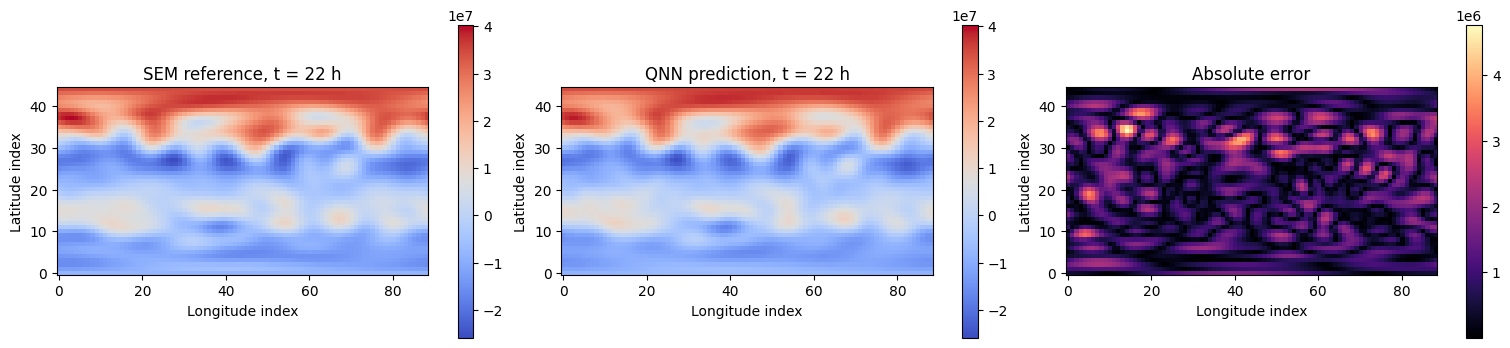

In [2]:
import numpy as np
import matplotlib.pyplot as plt

results = np.load("exp1_results.npz")

psi_pred_training = results["psi_pred_training"]
psi_qcl_training = results["psi_qcl_training"]
training_hours = results["training_hours"]

target_hour = 22
target_index = np.where(training_hours == target_hour)[0][0]

psi_sem_t22 = psi_qcl_training[target_index]
psi_qnn_t22 = psi_pred_training[target_index]
absolute_error_t22 = np.abs(psi_qnn_t22 - psi_sem_t22)

vmin = min(psi_sem_t22.min(), psi_qnn_t22.min())
vmax = max(psi_sem_t22.max(), psi_qnn_t22.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(psi_sem_t22, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("SEM reference, t = 22 h")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(psi_qnn_t22, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("QNN prediction, t = 22 h")
axes[1].set_xlabel("Longitude index")
axes[1].set_ylabel("Latitude index")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(absolute_error_t22, cmap="magma", origin="lower")
axes[2].set_title("Absolute error")
axes[2].set_xlabel("Longitude index")
axes[2].set_ylabel("Latitude index")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

plt.savefig("exp1_real_data_comparison_t22.png", dpi=200, bbox_inches="tight")
plt.show()

In [3]:
!pip install cartopy

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----------- ---------------------------- 3.1/11.0 MB 15.4 MB/s eta 0:00:01
   ------------------------------ --------- 8.4/11.0 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 20.2 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------------------------- - 6.0/6.3 MB 28.4 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 24.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [pyshp]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -------------------------- 1/3 [pyproj]
   ------------- -----

c:\Users\CyrilDELOINCE\miniconda3\envs\myenv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


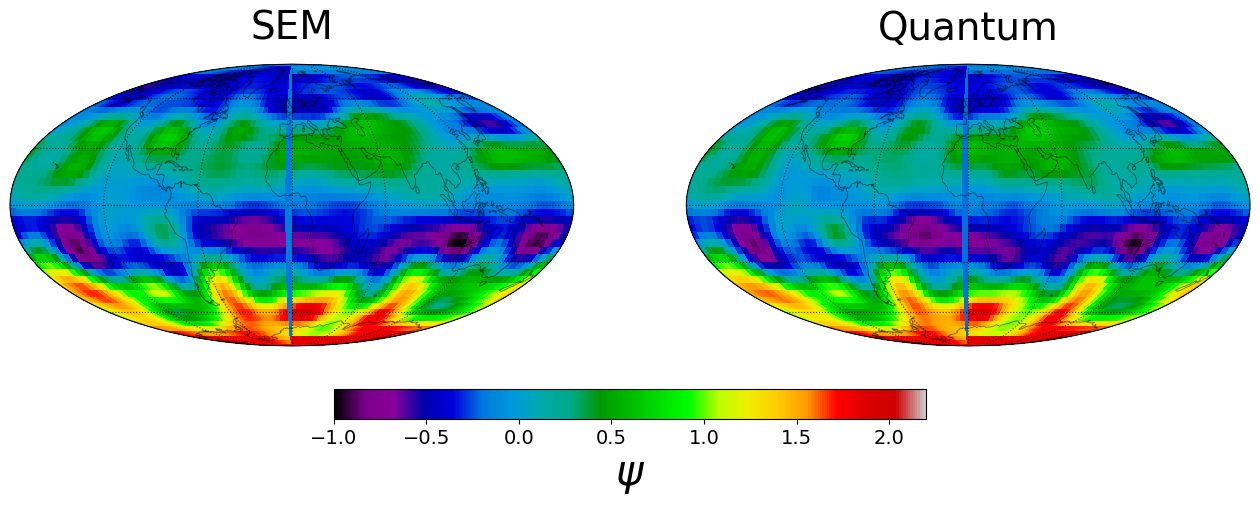

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load saved Exp1 predictions/results.
exp1_results = np.load("exp1_results.npz")

psi_pred_training = exp1_results["psi_pred_training"]
psi_qcl_training = exp1_results["psi_qcl_training"]
training_hours = exp1_results["training_hours"]

# Load lat/lon from the SEM dataset.
sem_data = np.load("sem_supervised_dataset.npz")
lat_downsampled = sem_data["lat_downsampled"]
lon_downsampled = sem_data["lon_downsampled"]

# Paper figure: t = 22 h.
target_hour = 22
target_index = np.where(training_hours == target_hour)[0][0]

psi_sem_t22 = psi_qcl_training[target_index]
psi_qnn_t22 = psi_pred_training[target_index]

# Visual scaling only, to mimic the paper colorbar around [-1, 2].
# Metrics should still use raw psi, not this scaled version.
psi_min = psi_sem_t22.min()
psi_max = psi_sem_t22.max()

psi_sem_plot = 3.0 * (psi_sem_t22 - psi_min) / (psi_max - psi_min) - 1.0
psi_qnn_plot = 3.0 * (psi_qnn_t22 - psi_min) / (psi_max - psi_min) - 1.0

lon_grid, lat_grid = np.meshgrid(lon_downsampled, lat_downsampled)

projection = ccrs.Mollweide(central_longitude=0)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 7))

ax_sem = fig.add_subplot(1, 2, 1, projection=projection)
ax_qnn = fig.add_subplot(1, 2, 2, projection=projection)

for ax, field, title in [
    (ax_sem, psi_sem_plot, "SEM"),
    (ax_qnn, psi_qnn_plot, "Quantum"),
]:
    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        field,
        transform=data_crs,
        cmap="nipy_spectral",
        vmin=-1.0,
        vmax=2.2,
        shading="auto",
    )

    ax.set_global()
    ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="black",
        alpha=0.7,
        linestyle=":",
    )
    ax.coastlines(linewidth=0.6, alpha=0.5)
    ax.set_title(title, fontsize=28, pad=18)

cbar = fig.colorbar(
    mesh,
    ax=[ax_sem, ax_qnn],
    orientation="horizontal",
    fraction=0.055,
    pad=0.08,
)

cbar.set_label(r"$\psi$", fontsize=30)
cbar.ax.tick_params(labelsize=14)

plt.savefig("exp1_real_data_comparison_t22_cartopy.png", dpi=250, bbox_inches="tight")
plt.show()